In [26]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, AIMessage

load_dotenv(override=True)
checkpointer = InMemorySaver()

In [27]:
openai_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)
llm2 = ChatOpenAI(
    model="gpt-4.1-nano",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)

## Topics 

In [28]:
topics = [{
    "topic": "Small Business Defined",
    "notes": f"""Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. 
    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes
    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities."""
    },
    {
    "topic": "Small Business Impact",
    "notes": f"""There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created 
    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,
    demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting 
    new businesses, and improving
    public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000."""
    },
    {
    "topic": "Small Business Demographics",
    "notes": f"""43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.
    20.4% are owned by racial minorities, including 14.5% by Hispanics.
    6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.
    Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers."""
    }
    ]

## Schemas

In [56]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, MessagesState
from typing import Literal

class TopicState(MessagesState):
    topic: str
    question: str
    reply: str
    hint_taken: bool

In [57]:
class DialogueState(MessagesState):
    index: int
    max_index: int
    topics: list[TopicState]

In [58]:
def initialize_graph(state: DialogueState) -> DialogueState:
    state["topics"] = []
    state["max_index"] = len(topics)
    state["index"] = -1
    
    return state

In [59]:
def set_index(state: DialogueState) -> DialogueState:
    state["index"] += 1
    return state

In [60]:
from typing import Literal

def check_termination(state: DialogueState) -> Literal["continue", "terminate"]:
    return "terminate" if state["index"] >= state["max_index"] else "continue"

In [71]:
def set_question(state: DialogueState) -> DialogueState:
    topic_dict = topics[state["index"]]
    topic, notes, hint_taken = topic_dict["topic"], topics[state["index"]]["notes"], False

    question_prompt = f"""
    You are an examiner whose job is to prepare a conceptual question (subjective) on a topic using the notes provided to you.
    Topic: {topic}
    Notes: {notes}
    Keep the question simple, just to test a basic understanding. Do not provide the answer.
    """
    question = llm.invoke(question_prompt).content
    
    state["topics"].append({
        "topic": topic,
        "question": question,
        "hint_taken": hint_taken,
        "reply": "",
        "messages": []
    })
    return state
    

In [62]:
def get_student_answer(state: DialogueState):
    index = state["index"]
    
    if state["topics"][index]["hint_taken"]:   
        comment = state["topics"][index]["messages"][-1].content
        user_input = input(f"{comment} \n")
        state["topics"][index]["reply"] = user_input
    else:
        user_answer = input(state["topics"][index]["question"])
        state["topics"][index]["reply"] = user_answer
    
    return state

In [63]:
from pydantic import BaseModel

class EvalSchema(BaseModel):
    evaluation: Literal["satisfactory", "unsatisfactory"]
    comment: str

In [64]:
def evaluate(state: DialogueState) -> Literal["satisfactory", "unsatisfactory"]:  
    """
    Evaluate the user reply, using LLM.
    Returns satisfactory/unsatisfactory
    """
    index = state["index"]
    
    ai_prompt = f"""
        You have to analyze the user's reply to a question to check the understanding of a concept and tell whether
        it is acceptable using notes provided to you. 
        Return: satisfactory or unsatisfactory, along with some comment on the users answer. 
        If not satisfactory, give hint in the comment
        without giving complete answer.
        Keep user as the first person and address the answer to user only.
        Question: {state["topics"][index]["question"]}
        Notes: {topics[index]["notes"]}
        User's reply: {state["topics"][index]["reply"]}
    """
    
    llm_s = llm.with_structured_output(EvalSchema)
    evaluation = llm_s.invoke(ai_prompt)
    state["topics"][index]["messages"].append(AIMessage(content=evaluation.comment))
    
    if evaluation.evaluation == "satisfactory":        
        return "satisfactory"
    return "unsatisfactory"
            

In [65]:
def satisfactory(state):
    index = state["index"]
    comment = state["topics"][index]["messages"][-1].content
    user_input = input(f"{comment} \n Press any key to continue \n")
    return state

In [66]:
def unsatisfactory(state):
    index = state["index"]
    state["topics"][index]["hint_taken"] = True
    return state

## Build Graph

In [72]:
from langgraph.graph import StateGraph, END

builder = StateGraph(DialogueState)

builder.add_node("initialize_graph", initialize_graph)
builder.add_node("set_index", set_index)
builder.add_node("set_question", set_question)
builder.add_node("get_student_answer", get_student_answer)
builder.add_node("satisfactory", satisfactory)
builder.add_node("unsatisfactory", unsatisfactory)

builder.set_entry_point("initialize_graph")

builder.add_conditional_edges(
    "set_index",
    check_termination,
    {
        "terminate": END,
        "continue": "set_question",
    }
)
builder.add_conditional_edges(
    "get_student_answer", 
    evaluate,
    {
         "satisfactory": "satisfactory",
         "unsatisfactory": "unsatisfactory",
    }
)
builder.add_edge("initialize_graph", "set_index")
builder.add_edge("set_question", "get_student_answer")
builder.add_edge("satisfactory", "set_index")
builder.add_edge("unsatisfactory", "get_student_answer")


In [73]:
graph = builder.compile()

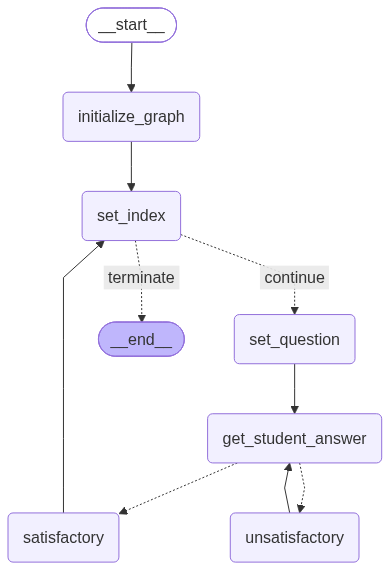

In [69]:
graph

In [74]:
state = {}
graph.invoke(state)

Question: 

Define a small business according to the Small Business Administration (SBA) and explain why small businesses are important to the economy and communities. Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base.      The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes     these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.
Your answer accurately defines a small business according to the SBA and explains its importance to the economy and communities. Well done! 
 Press any key to continue 
 
Question: Discuss the role of small businesses in the U.S. economy, highlighting their contribution to job creation, local economies, and resilience during economic challenges. Include specific statistics to support your points. There are over 33.2

{'messages': [],
 'index': 3,
 'max_index': 3,
 'topics': [{'topic': 'Small Business Defined',
   'question': 'Question: \n\nDefine a small business according to the Small Business Administration (SBA) and explain why small businesses are important to the economy and communities.',
   'hint_taken': False,
   'reply': 'Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base.      The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes     these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.',
   'messages': [AIMessage(content='Your answer accurately defines a small business according to the SBA and explains its importance to the economy and communities. Well done!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]},
  {